In [25]:
import glob
import os
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Load all files from one folder

D21_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/Tracking/Run20240215/Clean_files'
D21_path = os.path.join(D21_dir,'*.csv') 
D21_files = glob.glob(D21_path)

In [28]:
# Read csv files into list

D21_all_files = []

for file in D21_files:
    table = pd.read_csv(file)
    table.sort_values(by=["file_roi_particle", "frame"], inplace=True)
    D21_all_files.append(table)

D21_all_files[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name
0,0,1,335.879872,612.498656,5892.334128,3688.000000,0.366327,1.411553,861.861111,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
6,4,1,337.696727,614.071985,3660.075928,3911.406593,2.426232,2.370647,933.833333,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
8,5,1,338.554559,614.194560,4342.223471,4315.500000,1.841604,1.448669,985.527778,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
10,6,1,338.565542,614.210605,4100.836722,6726.055842,1.452800,1.293916,1072.361111,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
11,7,1,339.008871,615.038788,4755.401444,4810.000000,1.404138,1.438961,1022.305556,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...


In [51]:
def split_table_by_unique_id(df):
    """
    Splits each spots file into seperate dfs by file_roi_particle, so that spots can be sorted and filtered by frame' 
    """
    df = df.groupby("file_roi_particle", sort = False, as_index = False)
       
    return df

In [54]:
D21_singletracks0 = [j for i,j in split_table_by_unique_id(D21_all_files[0])]
D21_singletracks0[0].head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name
0,0,1,335.879872,612.498656,5892.334128,3688.000000,0.366327,1.411553,861.861111,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
6,4,1,337.696727,614.071985,3660.075928,3911.406593,2.426232,2.370647,933.833333,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
8,5,1,338.554559,614.194560,4342.223471,4315.500000,1.841604,1.448669,985.527778,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
10,6,1,338.565542,614.210605,4100.836722,6726.055842,1.452800,1.293916,1072.361111,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
11,7,1,339.008871,615.038788,4755.401444,4810.000000,1.404138,1.438961,1022.305556,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...


In [173]:
len(D21_singletracks0)

223

In [212]:
def calculate_D_single(single_traj: pd.DataFrame, deltat: float, min_length: int = 5):
    if len(single_traj) < min_length:
        return None
    
    x_values = single_traj.loc[:, "x"]
    y_values = single_traj.loc[:, "y"]
    
    # Calculate the squared difference between current and previous positions
    squared_diff = np.square(x_values - x_values.shift(1)) + np.square(y_values - y_values.shift(1))
    
    # Calculate the mean diffusion coefficient D
    D = squared_diff.mean() / (4 * deltat)
    #print(squared_diff.mean())
    
    particle = single_traj["particle"]
    df = pd.DataFrame({"D": D, "particle": particle})
    df = df.drop_duplicates()
    
    return df

In [211]:
def calculate_D(single_traj: pd.DataFrame, deltat: float, min_length: int = 5):
    if len(single_traj) < min_length:
        return None
    
    x_values = single_traj.loc[:, "x"]
    y_values = single_traj.loc[:, "y"]
    
    # Calculate the squared difference between current and previous positions
    squared_diff = np.square(x_values - x_values.shift(1)) + np.square(y_values - y_values.shift(1))
    
    # Calculate the mean diffusion coefficient D
    D = squared_diff.mean() / (4 * deltat)
    #print(squared_diff.mean())
       
    return D

In [213]:
instdiff_single = calculate_D_single(D21_singletracks0[3], 0.05)
print(instdiff_single)
print(type(instdiff_single))

None
<class 'NoneType'>


In [214]:
# Calculates instdiff for all tracks of one file  and filters out cases where calculate_D0 returns None
instdiff_single_all = [result for result in [calculate_D_single(track, 0.05) for track in D21_singletracks0] if result is not None]

# Concatenate the valid DataFrames
instdiff_all = pd.concat(instdiff_single_all)
instdiff_all.head(20)


,D,particle
0,11.301955,1
46,23.373522,13
50,5.236462,15
88,11.204041,20
89,3.845279,21
128,27.272267,26
135,15.898132,28
176,10.479384,32
3,8.242746,4
200,11.011578,41


In [221]:
# Calculates instantaneous diffusion coefficient for all tracks in a given file - not working yet!

def calculate_all_D(
    all_traj: pd.DataFrame, min_length: int = 5, radial: bool = False
):
    """
    """
    
    # Output results
    results = pd.DataFrame()
    

    # Loop for all tracks
    for track_id in all_traj["file_roi_particle"].unique():
        
        # Extract single trajectories and sort by frame
        single_traj = all_traj[all_traj["file_roi_particle"] == track_id].copy().sort_values(by="frame")
        
        # Filter out short tracks
        if len(single_traj) < min_length:
            continue
            
        # Calculate diffusion coefficient for single trajectory
        Diff = calculate_D(single_traj, 0.05)
        #print(Diff)
        # Create DataFrame to store results
        df_tmp = pd.DataFrame({"D": [Diff], "file_roi_particle": [track_id]})
        
        # Append results to output DataFrame
        results = pd.concat([results, df_tmp])
        results = results.drop_duplicates().reset_index(drop=True)
    return results

In [222]:
# Calculate D
instdiff = calculate_all_D(D21_all_files[0])
instdiff.head(20)

,D,file_roi_particle
0,11.301955,9_1_1
1,23.373522,9_1_13
2,5.236462,9_1_15
3,11.204041,9_1_20
4,3.845279,9_1_21
5,27.272267,9_1_26
6,15.898132,9_1_28
7,10.479384,9_1_32
8,8.242746,9_1_4
9,11.011578,9_1_41


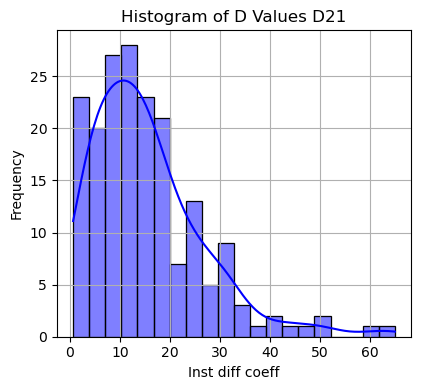

In [223]:
# Plot histogram for 'Inst diff coeff'

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=instdiff['D'].dropna(), bins=20, color='blue', kde=True)
plt.xlabel('Inst diff coeff')
#plt.xlim(-2,1)
#plt.ylim(0,50)
#ax.set_xticks(range(1,32))
plt.ylabel('Frequency')
plt.title('Histogram of D Values D21')
plt.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [210]:
All_files = pd.concat(D21_all_files)
All_files.head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,file_roi_particle,unique_id,line,day,batch,file_name
0,0,1,335.879872,612.498656,5892.334128,3688.000000,0.366327,1.411553,861.861111,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
6,4,1,337.696727,614.071985,3660.075928,3911.406593,2.426232,2.370647,933.833333,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
8,5,1,338.554559,614.194560,4342.223471,4315.500000,1.841604,1.448669,985.527778,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
10,6,1,338.565542,614.210605,4100.836722,6726.055842,1.452800,1.293916,1072.361111,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...
11,7,1,339.008871,615.038788,4755.401444,4810.000000,1.404138,1.438961,1022.305556,1,9_1_1,185,TUBB2B-KI,21,20230223,100tp_561-100-50ms-1000g_5_conf561_merged_spot...


In [132]:
def calculate_D1(single_traj: pd.DataFrame, deltat: float, min_length: int = 5):
    if len(single_traj) < min_length:
        return np.nan
    
    tvalues = single_traj["frame"].values
    tvalues = tvalues[:, None] - tvalues

    lags = np.arange(len(single_traj)) + 1
    x,y = np.where(tvalues == lags)
    
    squared_diff_mean = np.mean(
            
                np.square(
                single_traj.iloc[x][["x","y"]].values
                -single_traj.iloc[y][["x","y"]].values
                )
    )
    
    # Calculate the mean diffusion coefficient D
    D = squared_diff_mean / (4 * deltat)
    #print(squared_diff_mean)
    
    return D

In [116]:
def calculate_all_D1(
    all_traj: pd.DataFrame, min_length: int = 5, radial: bool = False
):
    # Output results
    results = pd.DataFrame()
    
    # Loop for all tracks
    for track_id in all_traj["file_roi_particle"].unique():
        
        # Extract single trajectories and sort by frame
        single_traj = all_traj[all_traj["particle"] == track_id].copy().sort_values(by="frame")
        
        # Filter out short tracks
        if len(single_traj) < min_length:
            continue
            
        # Calculate diffusion coefficient for single trajectory
        D = calculate_D1(single_traj, 0.05)
        
        # Create DataFrame to store results
        df_tmp = pd.DataFrame({"D": [D], "file_roi_particle": [track_id]})
        
        # Append results to output DataFrame
        results = pd.concat([results, df_tmp])
        
    return results

In [118]:
# Calculate D
instdiff = calculate_all_D1(D21_all_files[0])
instdiff.head(20)

40027.75892584681
96424.44737855029
6694.857602215374
101008.29485998946
6456.11043064347
112979.61645211042
15980.016687236757
155628.67171105344
23154.04714601798
2406.3399012340838
24304.08198700171
10454.899308876966
34424.289764407076
10848.18348108555
5417.518940603938
13505.16536136263
52286.632192590005
10686.20964184404
53074.86878777907
17824.135562974832
42637.114499838935
31387.64889456848
49987.94254483488
6897.613102021788
88783.62129880862
11894.099142808815
2872.1444047673526
2962.0997184085277
72922.24343148229
12402.9469734468
15349.240173582004
4027.1151554076173
140181.6676463878
41182.955189677305
28474.9556622442
0.568564244488895
23820.9728434264
1.9472186376101506
109385.18443944829
55676.22229498182
1.1501061110198838
4284.5172528066305
51805.6057869287
88685.689961945
19310.831100088242
95671.82936623323
4868.4659072166305
16671.181746638194
3965.7789942928666
2.330041166066079
1.9286386976700607
54305.41404462531
83721.11632702511
5.835564879574844
67744.6344

,D,particle
0,200138.794629,1
0,482122.236893,13
0,33474.288011,15
0,505041.474300,2
0,32280.552153,20
0,564898.082261,21
0,79900.083436,24
0,778143.358555,26
0,115770.235730,28
0,12031.699506,32


Are the x and y coordinates pixel values or um?
Which formula is correct, calculate_D0 or calculate_D1? D0 seems to be correct: sum of the squared differences of x and y equals r sqared.